In [89]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ulrikthygepedersen/online-retail-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\ulrikthygepedersen\online-retail-dataset\versions\2


In [90]:
# data prep
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

(Data Understanding)

In [91]:
# data read
files = os.listdir(path)
csv_files = [f for f in files if f.lower().endswith('.csv')]
if not csv_files:
    raise FileNotFoundError('no csv file found in downloaded dataset path')

csv_path = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_path, encoding_errors='ignore')
df.columns = [c.strip() for c in df.columns]

# create a simple target for grouped analysis charts
if 'Quantity' in df.columns:
    q_med = df['Quantity'].median()
    df['target'] = np.where(df['Quantity'] > q_med, 'high_qty', 'low_qty')
elif 'UnitPrice' in df.columns:
    p_med = df['UnitPrice'].median()
    df['target'] = np.where(df['UnitPrice'] > p_med, 'high_price', 'low_price')
else:
    df['target'] = 'all'

print('loaded:', csv_path)
print('shape:', df.shape)

loaded: C:\Users\User\.cache\kagglehub\datasets\ulrikthygepedersen\online-retail-dataset\versions\2\online_retail.csv
shape: (541909, 9)


In [92]:
# random sample data
sample_data = df.sample(min(5, len(df)))
sample_data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,target
128000,547249,22216,T-LIGHT HOLDER WHITE LACE,6,2011-03-22 09:27:00,1.63,NaN,United Kingdom,high_qty
355278,567915,23289,DOLLY GIRL CHILDRENS BOWL,8,2011-09-22 17:15:00,1.25,12579.0,France,high_qty
86045,543533,22212,FOUR HOOK WHITE LOVEBIRDS,1,2011-02-09 13:00:00,4.13,NaN,United Kingdom,low_qty
497454,C578371,22434,BALLOON PUMP WITH 10 BALLOONS,-2,2011-11-24 11:16:00,1.95,14410.0,United Kingdom,low_qty
339349,566589,23201,JUMBO BAG ALPHABET,10,2011-09-13 14:50:00,2.08,14753.0,United Kingdom,high_qty


In [93]:
#Size of Data
df.shape

(541909, 9)

In [94]:
#Information of Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
 8   target       541909 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 37.2+ MB


In [95]:
#Check Names of Columns
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'target'],
      dtype='object')

In [96]:
#Check Description
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [97]:
# Number of Unique Columns
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
target             2
dtype: int64

In [98]:
# Check Balance Of Data
df['target'].value_counts()

target
low_qty     277801
high_qty    264108
Name: count, dtype: int64

In [99]:
df['target'].value_counts(normalize=True) * 100

target
low_qty     51.263404
high_qty    48.736596
Name: proportion, dtype: float64

**data clean**

In [100]:
# Remove duplicate rows
df = df.drop_duplicates()
df.shape


(536641, 9)

In [101]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'target'],
      dtype='object')

In [102]:
# fix column names
df.columns = [col.lower().replace(' ', '_').strip() for col in df.columns]
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'target'],
      dtype='object')

In [103]:
# correct data type
num_features = [c for c in df.columns if c != 'target' and df[c].dtype != 'object']
for col in num_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

if 'target' in df.columns:
    df['target'] = df['target'].astype('category')

df.dtypes
df.isnull().sum()

invoiceno           0
stockcode           0
description      1454
quantity            0
invoicedate         0
unitprice           0
customerid     135037
country             0
target              0
dtype: int64

In [104]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
quantity,536641.0,9.620029,219.130156,-80995.00,1.00,3.00,10.00,80995.0
unitprice,536641.0,4.632656,97.233118,-11062.06,1.25,2.08,4.13,38970.0
customerid,401604.0,15281.160818,1714.006089,12346.00,13939.00,15145.00,16784.00,18287.0


In [105]:
#remove invlid values
cat_cols = ['target']

for col in cat_cols:
    if col in df.columns:
        print(f'========== {col} ==========')
        print('Unique Values:', df[col].unique())
        print(50 * '=')

========== target ==========
Unique Values: ['high_qty', 'low_qty']
Categories (2, object): ['high_qty', 'low_qty']


In [106]:
# standardize target values
df['target'] = df['target'].astype(str).str.lower().str.strip()
df['target'].unique()

array(['high_qty', 'low_qty'], dtype=object)

In [107]:
# fix numeric precision
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'target']

for col in num_cols:
    df[col] = df[col].round(2)

df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,target
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,high_qty
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,high_qty
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,high_qty
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,high_qty
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,high_qty


In [108]:
# outlier detection (iqr method)
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'target']
outlier_dict = {}

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_dict[col] = outliers.shape[0]

print('outliers found:', outlier_dict)

outliers found: {'quantity': 58501, 'unitprice': 39450, 'customerid': 0}


In [109]:
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    df = df[(df[col] >= q1 - 1.5 * iqr) & (df[col] <= q3 + 1.5 * iqr)]

print('outliers removed. final data shape:', df.shape)

outliers removed. final data shape: (328149, 9)


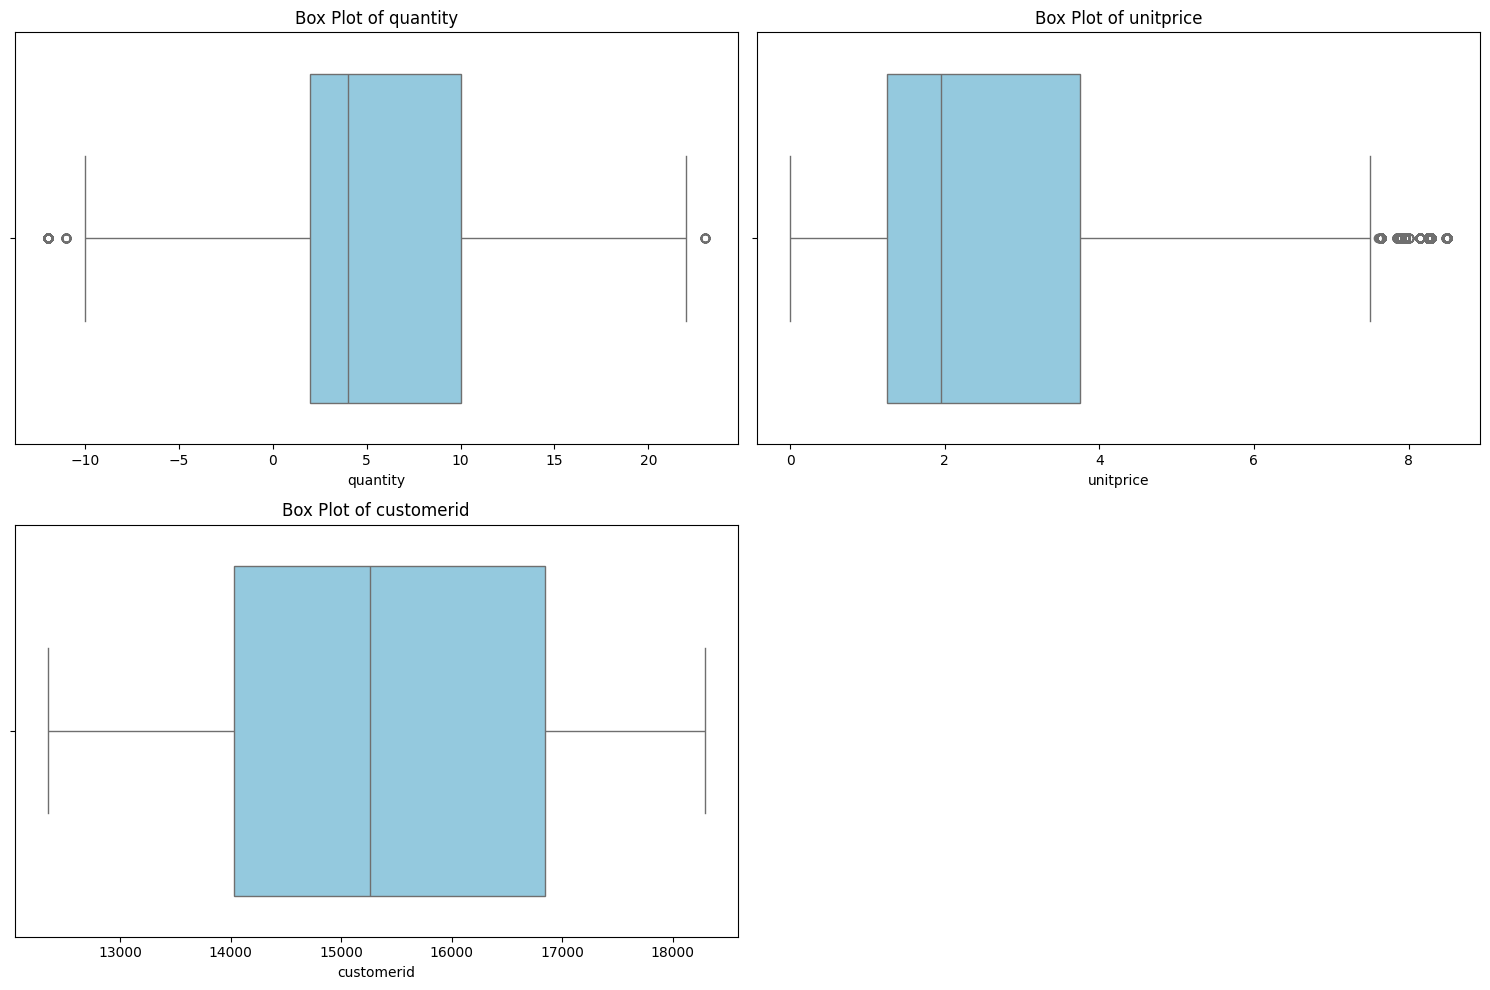

In [110]:
# Check Outlier
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

EDA

In [111]:
# Numerical features
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object','category']).columns

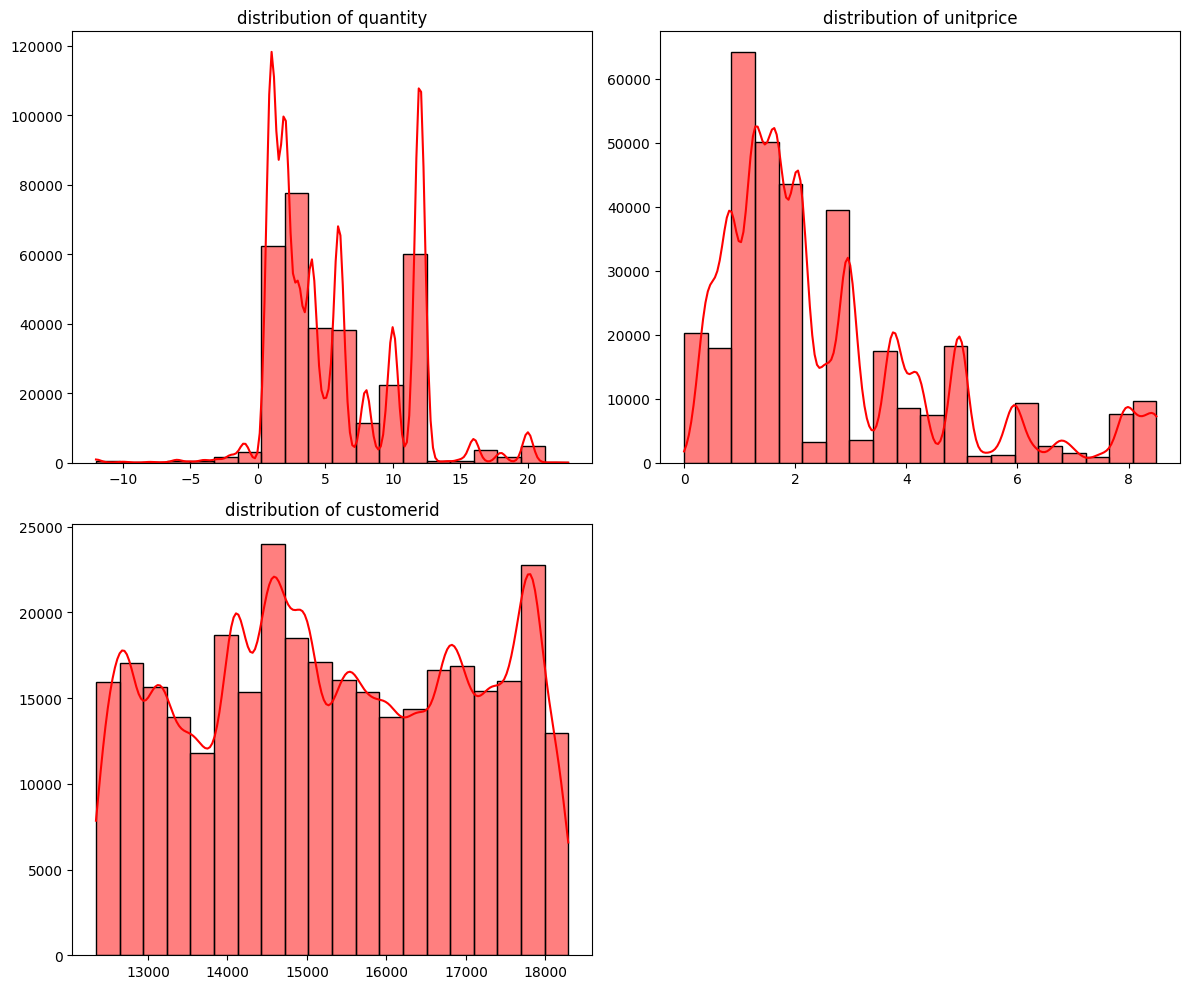

In [112]:
plots_per_row = 2
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'target'][:4]

plt.figure(figsize=(12, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col], kde=True, bins=20, color='red')
    plt.title(f'distribution of {col}', fontsize=12)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_7480\452318061.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='pastel')


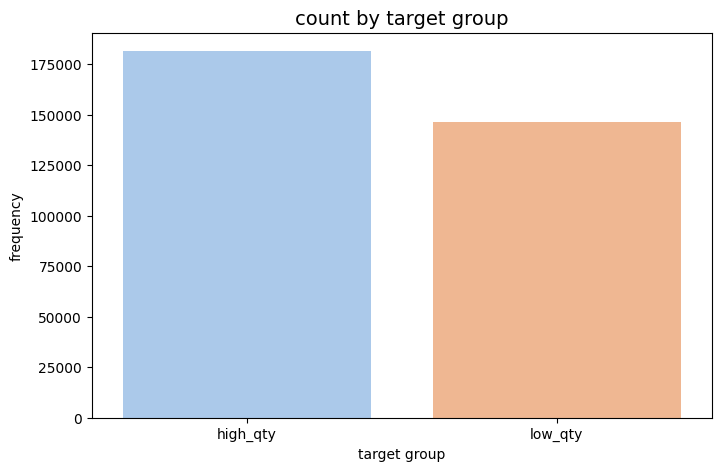

In [113]:
# count plots for target
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='target', palette='pastel')
plt.title('count by target group', fontsize=14)
plt.xlabel('target group')
plt.ylabel('frequency')
plt.show()

In [114]:
# Skewness and Kurtosis
'''
Skewness = if Skewness > 1 [skew]
Skewness = if Skewness > 2 [Outliers]
Kurtosis = if Kurtosis = 0 [Normal]
Kurtosis = if Kurtosis =   [Normal]
'''
skew_kurt = pd.DataFrame({
    'Feature': num_cols,
    'Skewness': [df[col].skew() for col in num_cols],
    'Kurtosis': [df[col].kurt() for col in num_cols]
})

print("Skewness and Kurtosis for numerical features:")
print(skew_kurt)

Skewness and Kurtosis for numerical features:
      Feature  Skewness  Kurtosis
0    quantity  0.654354  0.126039
1   unitprice  1.336040  1.183511
2  customerid -0.000153 -1.177776


In [115]:
# Since all skewness values are between -0.5 and 0.5,
# the data is well-distributed and no Log Transformation is needed.

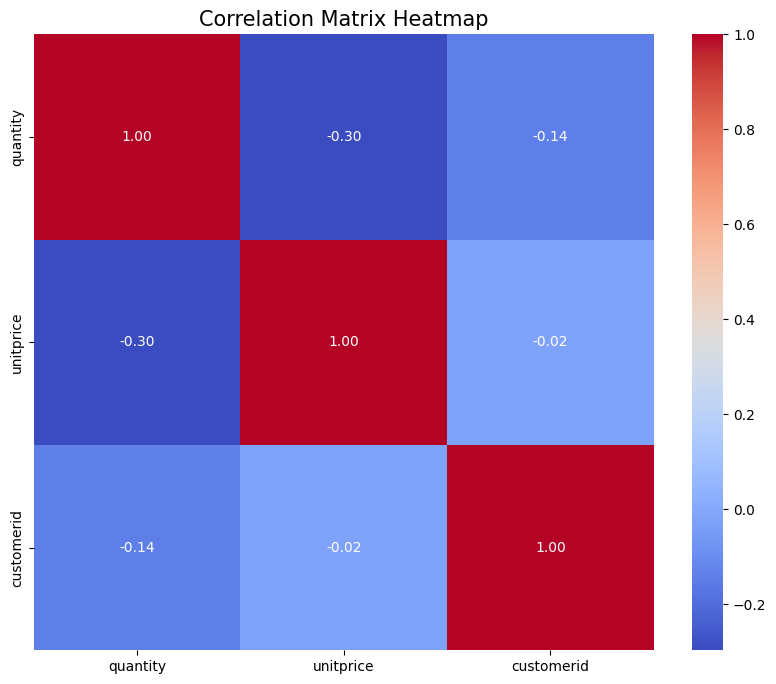

In [116]:
# Correlation Matrix and Heatmap

corr_matrix = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix Heatmap', fontsize=15)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_7480\2266326147.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=col, palette='Set3')
C:\Users\User\AppData\Local\Temp\ipykernel_7480\2266326147.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=col, palette='Set3')
C:\Users\User\AppData\Local\Temp\ipykernel_7480\2266326147.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=col, palette='Set3')


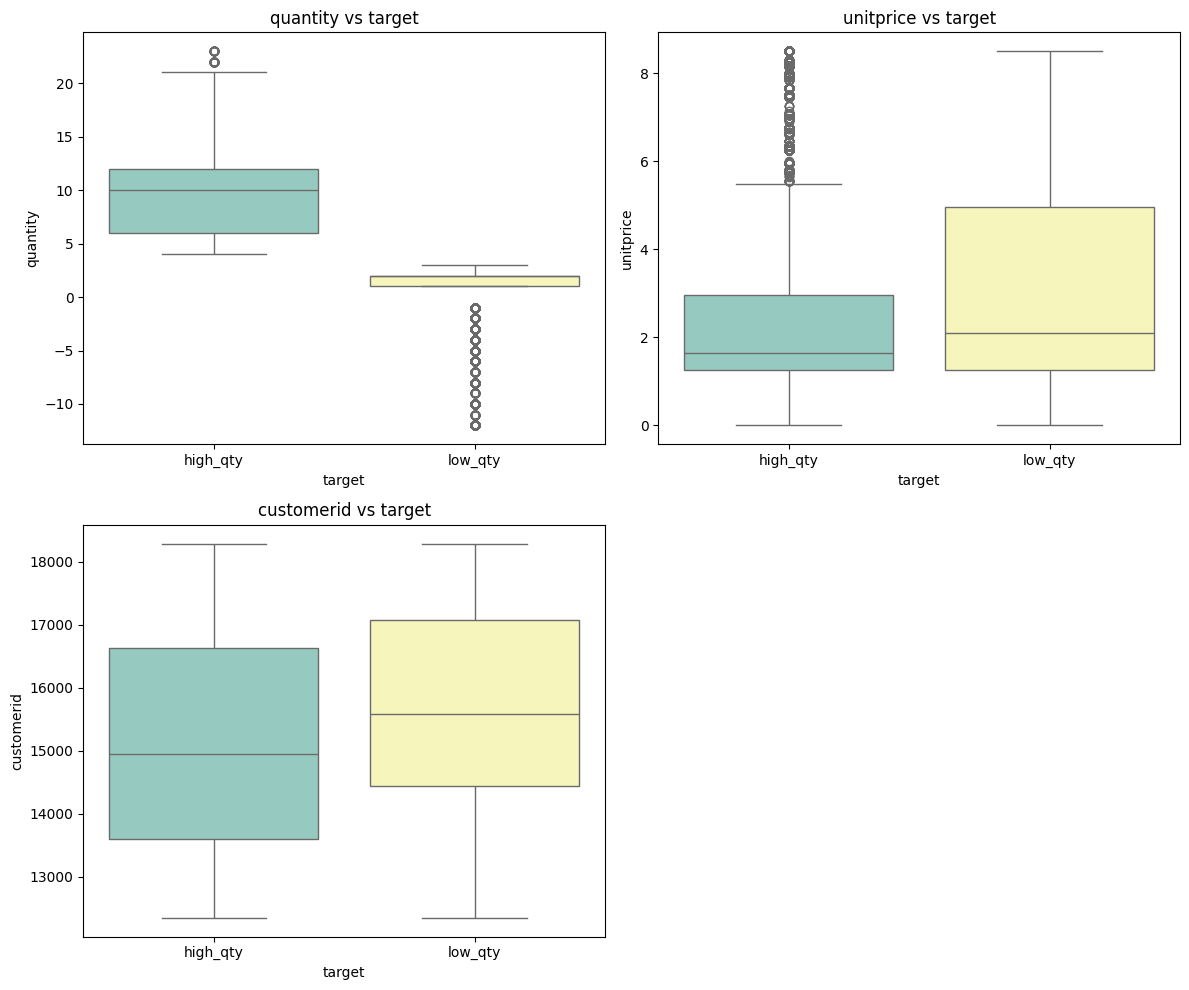

In [117]:
# boxplots (categorical vs numerical)
plt.figure(figsize=(12, 10))

for i, col in enumerate(num_cols[:4]):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df, x='target', y=col, palette='Set3')
    plt.title(f'{col} vs target', fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_7480\3005500612.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='target', y=col, palette='magma')
C:\Users\User\AppData\Local\Temp\ipykernel_7480\3005500612.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='target', y=col, palette='magma')
C:\Users\User\AppData\Local\Temp\ipykernel_7480\3005500612.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='target', y=col, palette='magma')


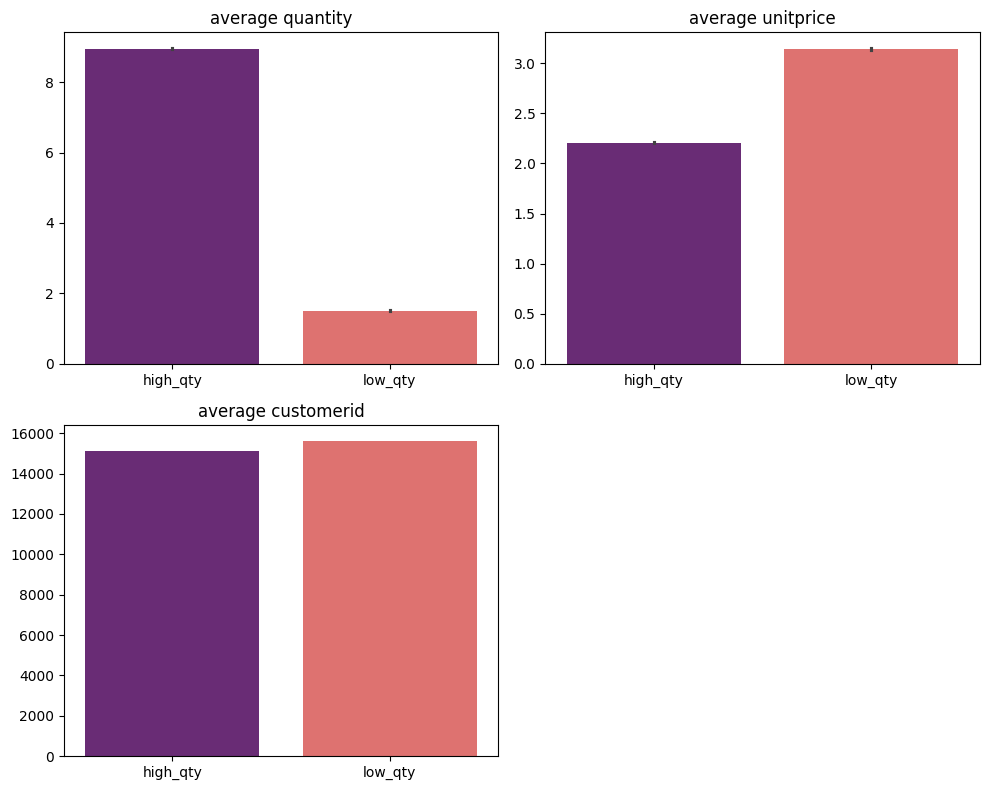

In [118]:
# barplots
plt.figure(figsize=(10, 8))
for i, col in enumerate(num_cols[:4]):
    plt.subplot(2, 2, i + 1)
    sns.barplot(data=df, x='target', y=col, palette='magma')
    plt.title(f'average {col}')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

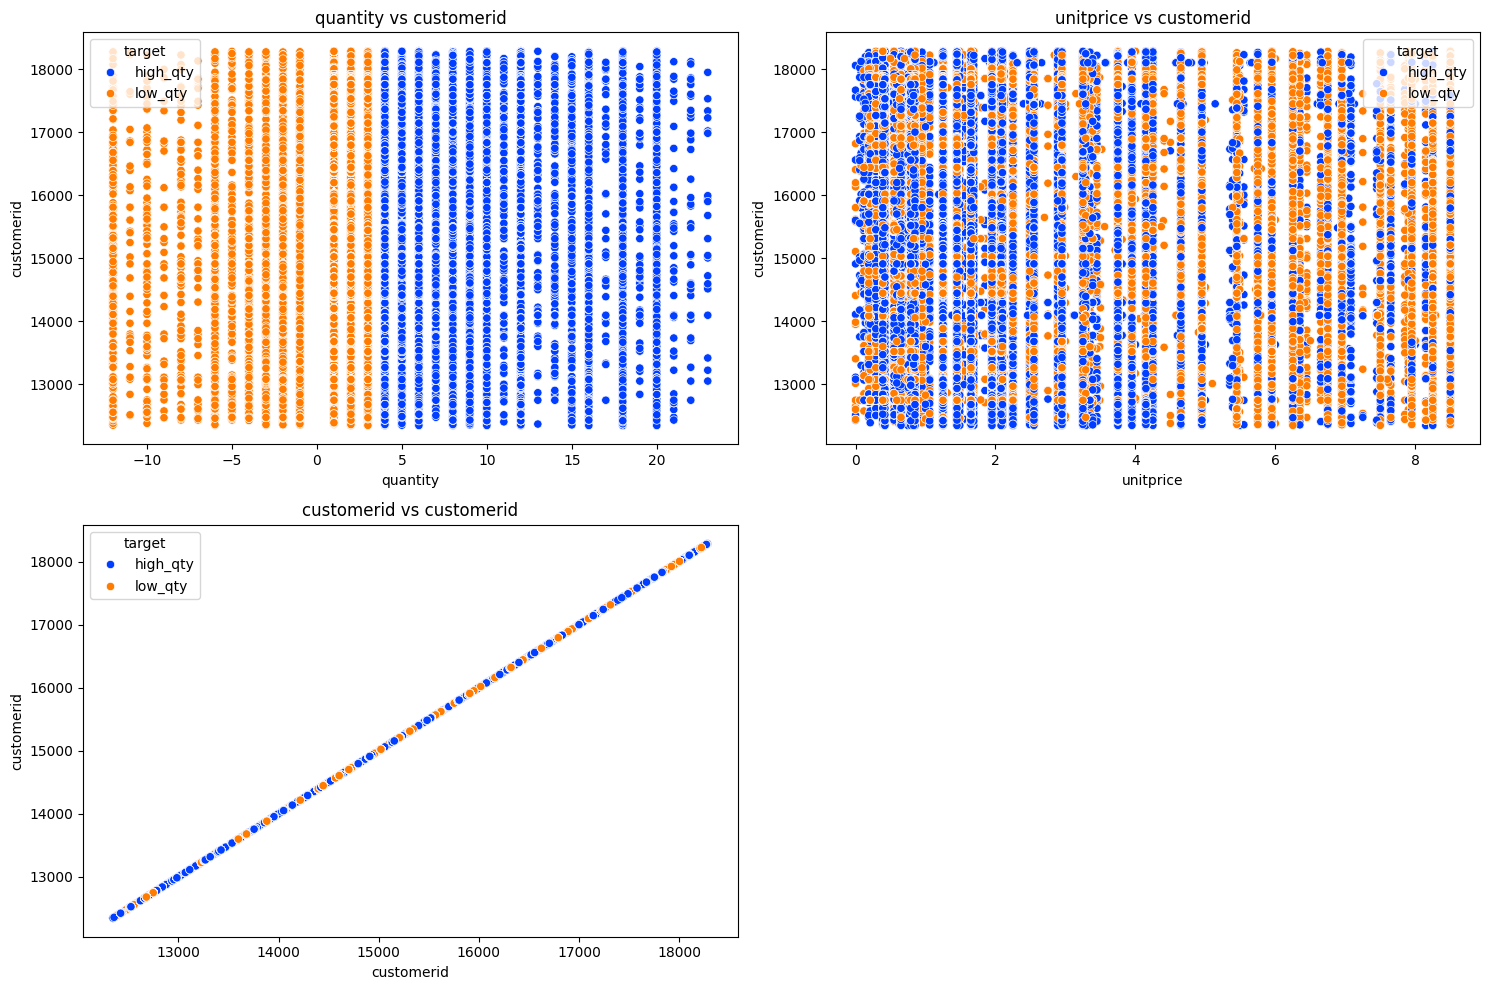

In [119]:
# scatter plots
plt.figure(figsize=(15, 10))
features = [c for c in num_cols if c != 'target'][:4]
y_col = features[-1] if features else None

for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    if y_col is not None:
        sns.scatterplot(data=df, x=col, y=y_col, hue='target', palette='bright')
        plt.title(f'{col} vs {y_col}')

plt.tight_layout()
plt.show()

In [120]:
# groupby aggregations ==> average of each feature per target
for col in num_cols:
    print(f'\nmean of {col} grouped by target:')
    print(df.groupby('target')[col].mean())


mean of quantity grouped by target:
target
high_qty    8.948711
low_qty     1.508325
Name: quantity, dtype: float64

mean of unitprice grouped by target:
target
high_qty    2.207875
low_qty     3.140870
Name: unitprice, dtype: float64

mean of customerid grouped by target:
target
high_qty    15104.402172
low_qty     15624.817366
Name: customerid, dtype: float64


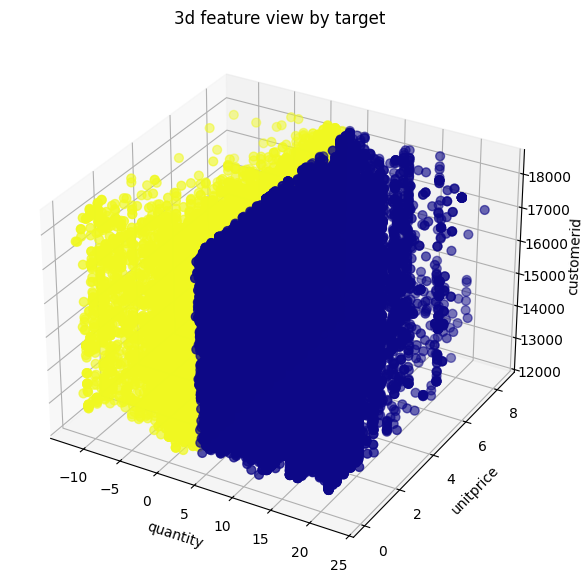

In [121]:
# 3d scatter plot
features_3d = [c for c in num_cols if c != 'target'][:3]

if len(features_3d) == 3:
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(
        df[features_3d[0]],
        df[features_3d[1]],
        df[features_3d[2]],
        c=df['target'].factorize()[0],
        cmap='plasma',
        s=40
    )

    ax.set_xlabel(features_3d[0])
    ax.set_ylabel(features_3d[1])
    ax.set_zlabel(features_3d[2])
    plt.title('3d feature view by target')
    plt.show()
else:
    print('not enough numeric features for 3d plot')

In [122]:
# vif
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.select_dtypes(include=[np.number]).copy()
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_data.sort_values(by='VIF', ascending=False))

,Feature,VIF
2,customerid,4.839162
1,unitprice,2.818742
0,quantity,2.399187


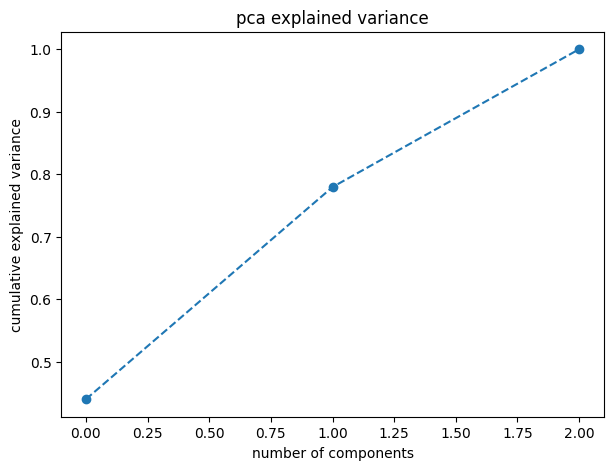

In [123]:
# pca
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df.select_dtypes(include=[np.number]).copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.title('pca explained variance')
plt.show()

## data preprocessing (requirements 1.4)

In [124]:
# 1.4.0 setup + working copy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

prep_df = df.copy()
print('start shape:', prep_df.shape)

start shape: (328149, 9)


In [125]:
# 1.4.1 Preprocessing: Dropping ID-like columns
prep_df = df.copy()

id_cols = ['invoice', 'stock', 'description', 'customer', 'date', 'id', 'code']

for col in prep_df.columns:
    for word in id_cols:
        if word in col.lower() and col.lower() != 'target':
            prep_df.drop(columns=[col], inplace=True)
            break

print('Columns after dropping IDs:', prep_df.columns.tolist())

Columns after dropping IDs: ['quantity', 'unitprice', 'country', 'target']


In [126]:
# Encoding selected categorical columns
cat_cols = prep_df.select_dtypes(include=['object', 'category']).columns
keep_cat_cols = []

for col in cat_cols:
    if col != 'target':
        # بنختار اللي الـ cardinality بتاعتهم قليلة
        if prep_df[col].nunique() <= 10:
            keep_cat_cols.append(col)

            # Label Encoding باستخدام factorize
            prep_df[col] = prep_df[col].astype(str).str.strip().fillna('missing')
            prep_df[col], _ = pd.factorize(prep_df[col])

            if len(keep_cat_cols) == 2:
                break

print('Kept and encoded:', keep_cat_cols)

Kept and encoded: []


In [127]:
# Dropping remaining categorical columns
for col in cat_cols:
    if col not in keep_cat_cols and col in prep_df.columns:
        prep_df.drop(columns=[col], inplace=True)

print('Final data shape:', prep_df.shape)
prep_df.head()

Final data shape: (328149, 2)


,quantity,unitprice
0,6,2.55
1,6,3.39
2,8,2.75
3,6,3.39
4,6,3.39


In [128]:
# 1.4.2 handle missing values

# بنحدد الأعمدة الرقمية اللي محتاجة تعويض
num_cols_p = prep_df.select_dtypes(include=[np.number]).columns

# بنعوض القيم الفاضية بالـ Median لكل عمود
prep_df[num_cols_p] = prep_df[num_cols_p].fillna(prep_df[num_cols_p].median())

# نتأكد إن مفيش قيم فاضية تانية
missing_count = prep_df[num_cols_p].isnull().sum().sum()
print('Missing values after fill:', int(missing_count))

Missing values after fill: 0


In [129]:
# 1.4.3 log transformation for skewed numerical features

# هنحسب الـ skewness لكل الأعمدة الرقمية
skew_vals = prep_df[num_cols_p].skew().abs()

# مصفوفة للأعمدة اللي هنطبق عليها الـ log
skew_cols = []

for col in skew_vals.index:
    # بنختار العمود لو الـ skew عالي (أكبر من 1) وكل قيم العمود موجبة
    if skew_vals[col] > 1 and (prep_df[col] > 0).all():
        skew_cols.append(col)

        # بنطبق الـ Log transformation
        # استخدمنا log1p عشان نتفادى الـ Zero error لو ظهر
        prep_df[col] = np.log1p(prep_df[col])

print('Skewed columns found:', skew_cols)
print('Total log-transformed columns:', len(skew_cols))

Skewed columns found: []
Total log-transformed columns: 0


In [130]:
# 1.4.4 outlier detection & treatment (iqr clipping)

for col in num_cols_p:
    # حساب الـ quartiles والـ iqr بنفس طريقتك بالظبط
    q1 = prep_df[col].quantile(0.25)
    q3 = prep_df[col].quantile(0.75)
    iqr = q3 - q1

    # تحديد الحدود (Lower and Upper bounds)
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # بدل ما نمسح القيم، هنخلي القيم المتطرفة تقف عند الحدود دي
    prep_df[col] = prep_df[col].clip(lower=lower, upper=upper)

print('Outlier treatment using IQR clipping is done.')

Outlier treatment using IQR clipping is done.


In [131]:
# 1.4.5 Preparing Features and Target

# بنفصل التارجيت في متغير لوحده الأول
# استخدمنا try/except عشان لو العمود اتمسح قبل كده الكود ميعلقش
if 'target' in prep_df.columns:
    y_all = prep_df['target'].astype(str)
else:
    # لو مش موجود، ده معناه إنك شغلتي الخلية دي قبل كده
    # بنعيد بناؤها من df لو متاح، عشان y_all تفضل موجودة
    if 'target' in df.columns:
        y_all = df.loc[prep_df.index, 'target'].astype(str)
    else:
        raise KeyError("'target' column not found in both prep_df and df.")

# بنمسح التارجيت من الاكسات مع استخدام ignore عشان م يطلعش Error لو مش موجود
X_all = prep_df.drop(columns=['target'], errors='ignore').copy()

# بنكمل باقي الخطوات زي ما هي
X_all = X_all.select_dtypes(include=[np.number])

# تقليل عدد الأعمدة (الـ Variance)
max_features = 40
if X_all.shape[1] > max_features:
    top_cols = X_all.var().sort_values(ascending=False).head(max_features).index
    X_all = X_all[top_cols]

# تقليل عدد الصفوف (Sample)
max_rows = 15000
if len(X_all) > max_rows:
    X_all = X_all.sample(n=max_rows, random_state=42)
    y_all = y_all.loc[X_all.index]

print('Features selection done. Shape:', X_all.shape)

Features selection done. Shape: (15000, 2)


## ai tasks (section 2)

In [132]:
# 2.1 clustering (unsupervised)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_all.columns, index=X_all.index)
X_cluster = X_scaled_df.copy()

k_range = range(2, 8)
scores = {}

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)

    current_score = silhouette_score(X_cluster, labels, sample_size=2000, random_state=42)

    scores[k] = current_score
    print('k =', k, 'score =', round(current_score, 4))

best_k = max(scores, key=scores.get)
print('--------------------------')
print('Best k found:', best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

k = 2 score = 0.4514
k = 3 score = 0.5151
k = 4 score = 0.4881
k = 5 score = 0.4489
k = 6 score = 0.4686
k = 7 score = 0.4488
--------------------------
Best k found: 3


In [133]:
# 2.1 clustering (unsupervised)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 2.1.1 remove target labels from dataset
X_cluster = X_scaled_df.copy()

# 2.1.2 apply clustering algorithm
k_candidates = range(2, 8)
sil_scores = {}

for k in k_candidates:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl_tmp = km_tmp.fit_predict(X_cluster)
    sil_scores[k] = silhouette_score(X_cluster, lbl_tmp)

best_k = max(sil_scores, key=sil_scores.get)
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

print('best k:', best_k)
print('silhouette by k:', sil_scores)

best k: 3
silhouette by k: {2: np.float64(0.4492715539709374), 3: np.float64(0.5211835160657377), 4: np.float64(0.49780323719784714), 5: np.float64(0.4533674225404816), 6: np.float64(0.4727070773964939), 7: np.float64(0.45113255248636525)}


In [134]:
# 2.2 clustering evaluation metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_km = silhouette_score(X_cluster, cluster_labels)
dbi_km = davies_bouldin_score(X_cluster, cluster_labels)

print('silhouette score:', round(sil_km, 4))
print('davies-bouldin index:', round(dbi_km, 4))

silhouette score: 0.5212
davies-bouldin index: 0.6836


In [135]:
# 2.3 classification (supervised)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_all.astype(str))

class_ratio = pd.Series(y_encoded).value_counts(normalize=True).max()
use_balanced_weights = class_ratio > 0.7

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded if len(np.unique(y_encoded)) > 1 else None
)

cls_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced' if use_balanced_weights else None
)

cls_model.fit(X_train, y_train)
y_pred = cls_model.predict(X_test)

y_prob = None
if hasattr(cls_model, 'predict_proba'):
    y_prob = cls_model.predict_proba(X_test)

In [136]:
# 2.4 classification evaluation metrics
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print('accuracy:', round(acc, 4))
print('f1-score (weighted):', round(f1, 4))

# roc-auc (binary or multiclass)
try:
    if y_prob is not None:
        if len(np.unique(y_test)) == 2:
            roc_auc = roc_auc_score(y_test, y_prob[:, 1])
        else:
            roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
        print('roc-auc:', round(roc_auc, 4))
    else:
        print('roc-auc: not available (no predict_proba)')
except Exception as e:
    print('roc-auc: not available')

print('classification report:')
print(classification_report(y_test, y_pred, zero_division=0))

accuracy: 1.0
f1-score (weighted): 1.0
roc-auc: 1.0
classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1648
           1       1.00      1.00      1.00      1352

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [137]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced' if use_balanced_weights else None)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print('Random Forest Accuracy:', round(rf_acc, 4))
print('Random Forest F1-Score:', round(rf_f1, 4))

lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

print('Logistic Regression Accuracy:', round(lr_acc, 4))
print('Logistic Regression F1-Score:', round(lr_f1, 4))

models_compare = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'Accuracy': [rf_acc, lr_acc],
    'F1-Score': [rf_f1, lr_f1]
})

print('\nModel Comparison:')
print(models_compare.sort_values(by='F1-Score', ascending=False))

Random Forest Accuracy: 1.0
Random Forest F1-Score: 1.0
Logistic Regression Accuracy: 1.0
Logistic Regression F1-Score: 1.0

Model Comparison:
                 Model  Accuracy  F1-Score
0        Random Forest       1.0       1.0
1  Logistic Regression       1.0       1.0


In [138]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

reg_target = 'quantity'
if reg_target not in prep_df.columns:
    numeric_candidates = prep_df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_candidates) == 0:
        raise ValueError('No numeric column found for regression target.')
    reg_target = numeric_candidates[0]
    print('Fallback regression target:', reg_target)

X_reg = prep_df.drop(columns=[reg_target], errors='ignore').copy()
y_reg = prep_df[reg_target].copy()
X_reg = X_reg.select_dtypes(include=[np.number]).fillna(0)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print('X_reg shape:', X_reg.shape)


X_reg shape: (328149, 1)


In [139]:
reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_reg_train, y_reg_train)

y_reg_pred = reg_model.predict(X_reg_test)

print('Regression model training done.')

Regression model training done.


In [140]:
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

print('MAE  :', round(mae, 4))
print('RMSE :', round(rmse, 4))
print('R2   :', round(r2, 4))

MAE  : 3.5949
RMSE : 4.4642
R2   : 0.1299
